# 02 · Cellpose Baseline — cpsam

Runs **Cellpose-SAM (cpsam)** out-of-the-box on one selected BFP image patch.
No fine-tuning. Results feed into `03_model_comparison.ipynb`.

**Environment:** Cellpose 4.x (`cellpose`)

Cellpose 3 models (`cyto3`, `bact_fluor_cp3`) are generated separately with `scripts/run_cellpose3_baseline.py` in a Cellpose 3.x environment. Do not run those model names through Cellpose 4.x here; v4 can warn that the requested model was not found and silently fall back to the default cpsam model.

**Outputs:**
- `data/processed/comparison_patch_bfp.tif` — raw uint16 BFP patch (shared with Cellpose 3 and Omnipose scripts)
- `data/processed/masks_cpsam.tif`
- `figures/qc/baseline_cellpose_models.png`

In [30]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path
from cellpose import models
import time

from src.io import load_stack, split_image
from src.preprocess import normalize_for_segmentation

In [31]:
PROJECT_ROOT  = Path('/Users/alicehong/projects/cellpose-biosensor')
STACK_PATH    = PROJECT_ROOT / 'data/raw/16bit/Scene-01-20260416-C3M2_Tcol_1-A01Export-01_c1-4_stack.tif'
PIXEL_SIZE_UM = 0.035
DIAMETER_PX   = 1.5 / PIXEL_SIZE_UM
print(f'Diameter: {DIAMETER_PX:.1f} px')

# ── Grid (must match notebook 01 and 05) ──────────────────────────────────────
N_ROWS = 4
N_COLS = 4

# ── Patch to use for comparison — set manually or leave None for auto-select ──
# Auto-select picks the patch with highest BFP p85 and lowest autofl score.
# To override, set e.g. PATCH_ROW, PATCH_COL = 1, 2
PATCH_ROW = 3
PATCH_COL = 2

(PROJECT_ROOT / 'data/processed').mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / 'figures/qc').mkdir(parents=True, exist_ok=True)

Diameter: 42.9 px


## Load stack and select patch

In [32]:
print('Loading stack...')
stack = load_stack(STACK_PATH)
print(f'Stack: {stack.shape} {stack.dtype}  max={stack.max()}')

patches = split_image(stack[0], n_rows=N_ROWS, n_cols=N_COLS)

# Score each patch: reward BFP p85, penalise min(GFP,RFP)/BFP
print('\nPatch scores:')
print(f"  {'patch':>8}  {'BFP p85':>8}  {'autofl':>7}  {'score':>8}")
scored = []
for p in patches:
    b = stack[0][p['y0']:p['y0']+p['h'], p['x0']:p['x0']+p['w']].astype(float)
    g = stack[1][p['y0']:p['y0']+p['h'], p['x0']:p['x0']+p['w']].astype(float)
    r = stack[2][p['y0']:p['y0']+p['h'], p['x0']:p['x0']+p['w']].astype(float)
    bfp_sig = float(np.percentile(b, 85))
    autofl  = float(np.mean(np.minimum(g, r)) / (b.mean() + 1))
    score   = bfp_sig / (1 + 10 * autofl)
    scored.append((score, p['row'], p['col'], bfp_sig, autofl))
    print(f"  r{p['row']}c{p['col']}      {bfp_sig:>8.0f}  {autofl:>7.3f}  {score:>8.1f}")

scored.sort(reverse=True)
best_row, best_col = scored[0][1], scored[0][2]

# Apply manual override if set
sel_row = PATCH_ROW if PATCH_ROW is not None else best_row
sel_col = PATCH_COL if PATCH_COL is not None else best_col
patch   = next(p for p in patches if p['row'] == sel_row and p['col'] == sel_col)

print(f"\nSelected: r{sel_row}c{sel_col}  "
      f"({patch['h']}×{patch['w']} px = "
      f"{patch['h']*PIXEL_SIZE_UM:.1f}×{patch['w']*PIXEL_SIZE_UM:.1f} µm)"
      + ("  [auto]" if PATCH_ROW is None else "  [manual]"))

crop_raw  = stack[0][patch['y0']:patch['y0']+patch['h'],
                      patch['x0']:patch['x0']+patch['w']]
# Keep a display-normalized copy for plotting only. Model calls below use
# raw intensities and Cellpose's default internal normalization.
crop_norm = normalize_for_segmentation(crop_raw)

tifffile.imwrite(PROJECT_ROOT / 'data/processed/comparison_patch_bfp.tif',
                 crop_raw, compression='lzw')
print(f'Saved → {PROJECT_ROOT}/data/processed/comparison_patch_bfp.tif')

Loading stack...
Stack: (4, 6323, 6344) uint16  max=8131

Patch scores:
     patch   BFP p85   autofl     score
  r0c0           102    0.075      58.4
  r0c1           207    0.032     156.7
  r0c2            76    0.003      74.1
  r0c3            97    0.034      72.4
  r1c0           138    0.018     116.5
  r1c1           170    0.024     137.5
  r1c2            23    0.008      21.3
  r1c3            86    0.009      79.1
  r2c0           198    0.031     151.3
  r2c1           204    0.027     160.1
  r2c2            49    0.008      45.2
  r2c3            51    0.022      41.9
  r3c0           283    0.021     233.9
  r3c1           121    0.015     105.7
  r3c2            68    0.066      40.9
  r3c3            13    0.007      12.1

Selected: r3c2  (1581×1586 px = 55.3×55.5 µm)  [manual]
Saved → /Users/alicehong/projects/cellpose-biosensor/data/processed/comparison_patch_bfp.tif


## Run Cellpose-SAM (cpsam)

Default model in Cellpose 4.x. Uses SAM backbone for improved boundary detection.

In [33]:
print('\n── Cellpose-SAM (cpsam) ──')
model_cpsam = models.CellposeModel(gpu=True)   # default = cpsam in 4.x

t0 = time.time()
masks_cpsam, flows_cpsam, _ = model_cpsam.eval(
    crop_raw.astype(np.float32),
    diameter=DIAMETER_PX,
    channels=[0, 0],    # grayscale, no nuclear channel
    flow_threshold=0.4,
    cellprob_threshold=0.0,
)
t_cpsam = time.time() - t0
n_cpsam = masks_cpsam.max()
print(f'cpsam: {n_cpsam} cells in {t_cpsam:.1f}s')

tifffile.imwrite(PROJECT_ROOT / 'data/processed/masks_cpsam.tif',
                 masks_cpsam.astype(np.uint16), compression='lzw')
print(f'Saved → {PROJECT_ROOT}/data/processed/masks_cpsam.tif')


── Cellpose-SAM (cpsam) ──


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


cpsam: 33 cells in 19.0s
Saved → /Users/alicehong/projects/cellpose-biosensor/data/processed/masks_cpsam.tif


## Cellpose 3 models

Run `scripts/run_cellpose3_baseline.py` in a Cellpose 3.x environment to generate `masks_cyto3.tif` and `masks_bact_fluor_cp3.tif`. They are not run in this notebook because Cellpose 4.x can fall back to cpsam when asked for CP3 model names.

## Summary

In [34]:
print(f'{"Model":<18} {"Cells":>6} {"Time":>8}')
print(f'{"cpsam":<18} {n_cpsam:>6} {t_cpsam:>7.1f}s')
print('\nCellpose 3 models: run scripts/run_cellpose3_baseline.py in a Cellpose 3.x env.')
print('Omnipose: run scripts/run_omnipose_baseline.py in the omnipose env next.')

Model               Cells     Time
cpsam                  33    19.0s

Cellpose 3 models: run scripts/run_cellpose3_baseline.py in a Cellpose 3.x env.
Omnipose: run scripts/run_omnipose_baseline.py in the omnipose env next.


## Quick visual (cpsam)

Figure saved -> /Users/alicehong/projects/cellpose-biosensor/figures/qc/baseline_cellpose_models.png


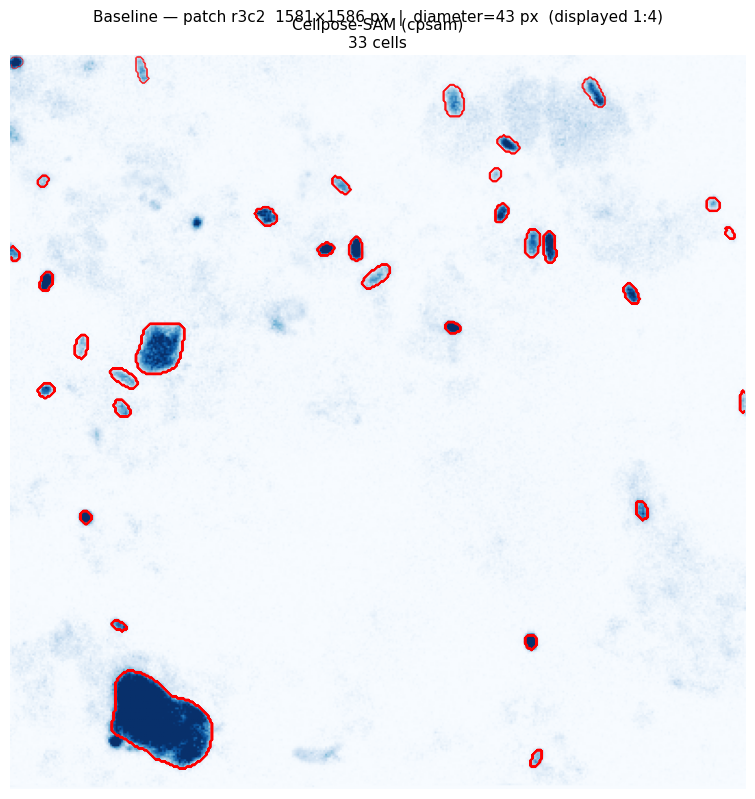

In [35]:
# Show a 1:4 thumbnail with contour overlays; the patch is large for full-res display.
THUMB = 4
thumb_norm = crop_norm[::THUMB, ::THUMB]

fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='White')

def outline_overlay(ax, img, masks, title, n_cells):
    ax.imshow(img, cmap='Blues', vmin=0, vmax=1)
    masks_thumb = masks[::THUMB, ::THUMB]
    if masks_thumb.max() > 0:
        ax.contour(masks_thumb, levels=np.arange(0.5, masks_thumb.max() + 0.5),
                   colors='red', linewidths=0.5)
    ax.set_title(f'{title}\n{n_cells} cells', color='Black', fontsize=11)
    ax.axis('off')

outline_overlay(ax, thumb_norm, masks_cpsam, 'Cellpose-SAM (cpsam)', n_cpsam)
fig.suptitle(
    f'Baseline — patch r{sel_row}c{sel_col}  '
    f'{patch["h"]}×{patch["w"]} px  |  diameter={DIAMETER_PX:.0f} px  '
    f'(displayed 1:{THUMB})',
    color='black', fontsize=11)
plt.tight_layout(pad=0.3)
plt.savefig(PROJECT_ROOT / 'figures/qc/baseline_cellpose_models.png',
            dpi=150, bbox_inches='tight', facecolor='white')
print(f'Figure saved -> {PROJECT_ROOT}/figures/qc/baseline_cellpose_models.png')
plt.show()